In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("/content/feature_engineered_data.csv")

In [ ]:
df.head(4)

,date,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2022-01-31,0,29.7,46,14.24,5,1,1.30,2022,1,31,0,0,24.17,25.48,26.65,23.034286,22.247333
1,2022-02-01,3,31.7,39,25.43,3,2,1.22,2022,2,1,1,0,14.24,17.76,25.32,24.130000,22.251000
2,2022-02-02,3,28.3,79,24.70,4,2,2.02,2022,2,2,2,0,25.43,27.13,23.40,23.782857,22.294333
3,2022-02-03,1,32.5,56,10.78,8,0,1.04,2022,2,3,3,0,24.70,31.90,20.51,20.765714,21.970000


In [ ]:
X = df.drop(columns=['date', 'electricity_units_kwh'])

In [ ]:
X

,city,temperature_c,humidity_percent,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,0,29.7,46,5,1,1.30,2022,1,31,0,0,24.17,25.48,26.65,23.034286,22.247333
1,3,31.7,39,3,2,1.22,2022,2,1,1,0,14.24,17.76,25.32,24.130000,22.251000
2,3,28.3,79,4,2,2.02,2022,2,2,2,0,25.43,27.13,23.40,23.782857,22.294333
3,1,32.5,56,8,0,1.04,2022,2,3,3,0,24.70,31.90,20.51,20.765714,21.970000
4,0,21.2,83,2,2,0.48,2022,2,4,4,0,10.78,28.42,29.20,18.852857,21.497667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,3,23.6,79,3,1,1.06,2026,2,4,2,0,18.42,26.75,33.67,21.674286,22.034333
1466,4,37.1,34,2,1,0.10,2026,2,5,3,0,20.20,18.58,11.07,22.855714,22.560333
1467,4,31.9,82,4,2,2.69,2026,2,6,4,0,26.85,27.11,18.41,21.624286,22.563000
1468,3,33.9,58,3,2,2.30,2026,2,7,5,1,18.49,14.62,24.22,22.035714,22.339000


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                1470 non-null   int64  
 1   temperature_c       1470 non-null   float64
 2   humidity_percent    1470 non-null   int64  
 3   household_size      1470 non-null   int64  
 4   income_level        1470 non-null   int64  
 5   power_outage_hours  1470 non-null   float64
 6   year                1470 non-null   int64  
 7   month               1470 non-null   int64  
 8   day                 1470 non-null   int64  
 9   day_of_week         1470 non-null   int64  
 10  is_weekend          1470 non-null   int64  
 11  lag_1               1470 non-null   float64
 12  lag_7               1470 non-null   float64
 13  lag_30              1470 non-null   float64
 14  rolling_mean_7      1470 non-null   float64
 15  rolling_mean_30     1470 non-null   float64
dtypes: flo

In [ ]:
y = df['electricity_units_kwh']

In [ ]:
y

,electricity_units_kwh
0,14.24
1,25.43
2,24.70
3,10.78
4,15.03
...,...
1465,20.20
1466,26.85
1467,18.49
1468,17.50


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, shuffle=False, random_state=42
)

In [ ]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)



In [ ]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 4.485758926106148
MSE : 30.258916852418626
RMSE: 5.500810563218717


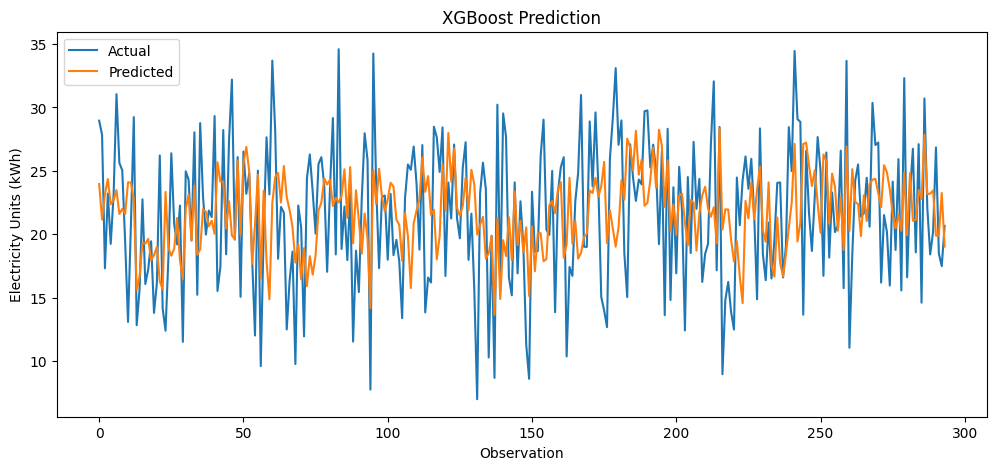

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("XGBoost Prediction")
plt.xlabel("Observation")
plt.ylabel("Electricity Units (kWh)")
plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse]
})

results.to_csv("xgboost_results.csv", index=False)

In [ ]:
import pickle

with open("xgboost.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
from google.colab import files

files.download("xgboost.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>